### Drive Mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import

In [3]:
# ==========================================================
# IMPORTS
# ==========================================================

import os
import glob
import random
import zipfile
import time
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    TensorDataset,
    WeightedRandomSampler
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# REPRODUCIBILITY
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cpu


### Zip Check

In [4]:
import os
import glob

zip_path = None

for z in glob.glob(
    "/content/drive/MyDrive/**/*.zip",
    recursive=True
):
    if "ZT_datasets.zip" in os.path.basename(z):
        zip_path = z
        break

print("ZIP:", zip_path)

ZIP: /content/drive/MyDrive/ZT_datasets.zip


### Extraction Complete


In [5]:
import zipfile
import os

extract_root = "/content/ZT_datasets"

os.makedirs(
    extract_root,
    exist_ok=True
)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

print("Extraction Complete")

Extraction Complete


### Content

In [6]:
import os

for root, dirs, files in os.walk("/content/ZT_datasets"):
    csvs = [f for f in files if f.endswith(".csv")]
    if len(csvs) > 0:
        print(root)
        print("CSV Files:", len(csvs))
        print("-"*50)

/content/ZT_datasets/ZT_datasets/UNSW
CSV Files: 8
--------------------------------------------------
/content/ZT_datasets/ZT_datasets/BoT
CSV Files: 70
--------------------------------------------------
/content/ZT_datasets/ZT_datasets/CIC
CSV Files: 5
--------------------------------------------------


### ROOT

In [7]:
# ==========================================================
# Setup
# ==========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

ROOT = "/content/ZT_datasets/ZT_datasets"
datasets = ["CIC", "UNSW", "BoT"]

Device: cpu


### Feature Config

In [8]:
# ==========================================================
# Feature Config
# ==========================================================
FEATURE_MAP = {
    "flow_duration": ["flow duration", "dur", "duration"],
    "tot_fwd_pkts": ["total fwd packets", "spkts"],
    "tot_bwd_pkts": ["total backward packets", "dpkts"],
    "totlen_fwd": ["total length of fwd packets", "sbytes"],
    "totlen_bwd": ["total length of bwd packets", "dbytes"],
    "flow_bytes_s": ["flow bytes/s"],
    "flow_pkts_s": ["flow packets/s"],
    "flow_iat_mean": ["flow iat mean"],
    "flow_iat_std": ["flow iat std"],
    "pkt_len_mean": ["packet length mean"],
    "pkt_len_std": ["packet length std"],
    "pkt_len_max": ["packet length max"],
    "pkt_len_min": ["packet length min"],
}

FEATURES = list(FEATURE_MAP.keys())
INPUT_DIM = len(FEATURES)

def _norm(s):
    return str(s).lower().strip()

def _is_binary_label_series(s: pd.Series) -> np.ndarray:
    """
    Convert common label series to binary 0/1.
    - benign/normal/clean/0 -> 0
    - attack/malicious/anomaly/1 -> 1
    - numeric > 0 -> 1, else 0
    """
    if pd.api.types.is_numeric_dtype(s):
        vals = pd.to_numeric(s, errors="coerce").fillna(0).astype(float)
        return (vals > 0).astype(int).values

    y = s.astype(str).str.lower().str.strip()

    benign_words = {
        "benign", "normal", "clean", "legit", "0", "false", "none", "safe"
    }
    attack_words = {
        "attack", "malicious", "malware", "anomaly", "1", "true", "bad"
    }

    # Direct mapping first
    out = np.where(y.isin(benign_words), 0, np.where(y.isin(attack_words), 1, np.nan))

    # Heuristic fallback
    if np.isnan(out).any():
        benign_mask = y.str.contains(r"benign|normal|clean|legit|safe", regex=True, na=False)
        out = np.where(benign_mask, 0, 1)

    return out.astype(int)

### Feature Extraction

In [9]:
# ==========================================================
# Feature Extraction
# ==========================================================
def extract_features(df):
    cols = {_norm(c): c for c in df.columns}
    out = []

    for feat in FEATURES:
        found = None
        for alias in FEATURE_MAP[feat]:
            alias_n = _norm(alias)
            if alias_n in cols:
                found = cols[alias_n]
                break

        if found is not None:
            out.append(pd.to_numeric(df[found], errors="coerce"))
        else:
            out.append(pd.Series(np.zeros(len(df)), index=df.index))

    X = pd.concat(out, axis=1)
    X = X.replace([np.inf, -np.inf], 0).fillna(0)
    return X.values.astype(np.float32)


### Label Extraction

In [10]:
# ==========================================================
# Label Extraction
# ==========================================================
def extract_labels(df):
    cols = {_norm(c): c for c in df.columns}

    # CICIDS-style
    if "label" in cols:
        return _is_binary_label_series(df[cols["label"]])

    # UNSW summary/category style
    if "attack category" in cols:
        return _is_binary_label_series(df[cols["attack category"]])

    # Common binary fields
    for key in ["attack", "class", "category", "target", "label"]:
        if key in cols:
            return _is_binary_label_series(df[cols[key]])

    # Fallback: search for a likely label-like column
    for c in df.columns:
        cn = _norm(c)
        if any(k in cn for k in ["label", "attack", "category", "class", "target"]):
            return _is_binary_label_series(df[c])

    print("WARNING: No label column found.")
    return np.zeros(len(df), dtype=int)


### Dataset Loading


In [14]:
# ==========================================================
# Dataset Loading
# ==========================================================
def load_dataset(path, max_rows=10000, min_feature_hits=2):
    files = glob.glob(f"{path}/**/*.csv", recursive=True)

    print(f"\nLoading path: {path}")
    print(f"CSV files: {len(files)}")

    if len(files) == 0:
        raise ValueError(f"No CSV files found under: {path}")

    dfs = []
    rows_per_file = max(1, max_rows // len(files))

    for f in files:
        try:
            df = pd.read_csv(
                f,
                low_memory=False,
                encoding="latin1",
                on_bad_lines="skip"
            )

            if df is None or df.empty:
                continue

            cols_norm = {_norm(c) for c in df.columns}
            feature_hits = 0
            for feat in FEATURES:
                for alias in FEATURE_MAP[feat]:
                    if _norm(alias) in cols_norm:
                        feature_hits += 1
                        break

            if feature_hits < min_feature_hits:
                print(f"Skipping (not enough feature columns): {os.path.basename(f)}")
                continue

            if len(df) > rows_per_file:
                df = df.sample(rows_per_file, random_state=SEED)

            dfs.append(df)

        except Exception as e:
            print(f"Skipping {f}")
            print(e)

    if len(dfs) == 0:
        raise ValueError(f"No usable CSVs found in {path}.")

    df = pd.concat(dfs, ignore_index=True, copy=False)
    df.columns = df.columns.str.lower().str.strip()

    X = extract_features(df)
    y = extract_labels(df)

    if len(X) != len(y):
        raise ValueError(f"Feature/label length mismatch in {path}: X={len(X)}, y={len(y)}")

    dist = dict(zip(*np.unique(y, return_counts=True)))
    print("Class Distribution:", dist)

    if len(dist) < 2:
        print(f"WARNING: {os.path.basename(path)} is single-class. Some metrics will not be meaningful.")

    return X, y


In [12]:
client_trains = []
client_tests = []
client_vals = []

for ds in datasets:

    Xf, yf = load_dataset(f"{ROOT}/{ds}")

    print(
        f"{ds} distribution:",
        dict(zip(*np.unique(yf, return_counts=True)))
    )

    unique_labels = np.unique(yf)

    strat = yf if (
        len(unique_labels) > 1
        and np.min(np.bincount(yf)) >= 2
    ) else None

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        Xf,
        yf,
        test_size=0.15,
        stratify=strat,
        random_state=SEED
    )

    strat2 = y_train_full if (
        len(np.unique(y_train_full)) > 1
        and np.min(np.bincount(y_train_full)) >= 2
    ) else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.15,
        stratify=strat2,
        random_state=SEED
    )

    client_trains.append(
        (X_train, y_train)
    )

    client_vals.append(
        (X_val, y_val)
    )

    client_tests.append(
        (X_test, y_test)
    )

# Scaling
all_train = np.vstack([X for X, _ in client_trains])

scaler = StandardScaler().fit(all_train)

client_trains = [
    (scaler.transform(X), y)
    for X, y in client_trains
]

client_vals = [
    (scaler.transform(X), y)
    for X, y in client_vals
]

client_tests = [
    (scaler.transform(X), y)
    for X, y in client_tests
]



Loading path: /content/ZT_datasets/ZT_datasets/CIC
CSV files: 5
Class Distribution: {np.int64(0): np.int64(9179), np.int64(1): np.int64(821)}
CIC distribution: {np.int64(0): np.int64(9179), np.int64(1): np.int64(821)}

Loading path: /content/ZT_datasets/ZT_datasets/UNSW
CSV files: 8
Skipping (not enough feature columns): UNSW-NB15_1.csv
Skipping (not enough feature columns): UNSW-NB15_2.csv
Skipping (not enough feature columns): UNSW-NB15_LIST_EVENTS.csv
Skipping (not enough feature columns): NUSW-NB15_features.csv
Skipping (not enough feature columns): UNSW-NB15_3.csv
Skipping (not enough feature columns): UNSW-NB15_4.csv
Class Distribution: {np.int64(0): np.int64(957), np.int64(1): np.int64(1543)}
UNSW distribution: {np.int64(0): np.int64(957), np.int64(1): np.int64(1543)}

Loading path: /content/ZT_datasets/ZT_datasets/BoT
CSV files: 70
Class Distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(9796)}
BoT distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(9796

### Model

In [15]:
# ==========================================================
# MLP IDS MODEL
# ==========================================================
class IDSModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(INPUT_DIM, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 2)

        )

    def forward(self, x):
        return self.network(x)

### Mixup

In [16]:
# ==========================================================
# Mixup
# ==========================================================
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


### Trust Components

In [17]:
# ==========================================================
# Trust Components
# ==========================================================
from numpy.linalg import norm

def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

def reliability_score(update):
    return 1.0 / (np.var(update) + 1e-6)

def compute_trust_score(acc, reliability, similarity, alpha=0.4, beta=0.3, gamma=0.3):
    return alpha * acc + beta * reliability + gamma * similarity

def trust_weighted_aggregation(global_model, local_weights, client_acc, client_updates=None):
    trust_scores = []

    global_vec = np.concatenate(
        [v.detach().cpu().numpy().flatten() for v in global_model.state_dict().values()]
    )

    for i, w in enumerate(local_weights):
        client_vec = np.concatenate([v.detach().cpu().numpy().flatten() for v in w.values()])

        sim = cosine_similarity(client_vec, global_vec)
        rel = reliability_score(client_vec)
        acc = client_acc[i]

        # Confidence-aware trust will be fed into client_acc before this point
        trust_scores.append(compute_trust_score(acc, rel, sim))

    trust_scores = np.array(trust_scores, dtype=np.float64)
    trust_scores = trust_scores / (trust_scores.sum() + 1e-12)

    new_state = {}
    for key in global_model.state_dict().keys():
        agg = 0
        for i in range(len(local_weights)):
            agg += trust_scores[i] * local_weights[i][key]
        new_state[key] = agg

    return new_state, trust_scores


## Class Weights

In [18]:
# ==========================================================
# Class Weights
# ==========================================================
all_y_train = np.concatenate([y for _, y in client_trains]).astype(int)
class_counts = np.bincount(all_y_train, minlength=2)

class_weights = len(all_y_train) / (2.0 * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights:", class_weights.detach().cpu().numpy())


Class weights: [1.0995904 0.9169513]


### Federated Training

In [19]:
import time
import os
import psutil

# ==========================================================
# Federated Training
# ==========================================================
def federated_train(
    rounds=20,
    local_epochs=8,
    use_trust=True,
    use_class_weights=True,
    use_sampler=True,
    use_mixup=True,
    use_fedprox=False,
    mu=0.01
):
    global_model = IDSModel().to(DEVICE)

    # Conditional class weights for loss function
    current_class_weights = class_weights if use_class_weights else None
    loss_fn = nn.CrossEntropyLoss(weight=current_class_weights)

    trust_history = []
    round_history = []

    for r in range(rounds):
        round_start = time.time()

        local_weights = []
        client_acc = []
        client_updates = []

        for k in range(K):
            X, y = client_trains[k]
            y = y.astype(int)

            model = IDSModel().to(DEVICE)
            model.load_state_dict(global_model.state_dict())

            # FedProx reference parameters (global model snapshot)
            global_params = None
            if use_fedprox:
                global_params = {
                    name: param.detach().clone()
                    for name, param in model.named_parameters()
                }

            optimizer = optim.AdamW(
                model.parameters(),
                lr=1e-3,
                weight_decay=1e-4
            )

            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer,
                T_0=3,
                T_mult=2
            )

            # Conditional weighted sampler
            if use_sampler:
                class_counts_local = np.bincount(y, minlength=2)

                sample_weights = np.array(
                    [
                        1.0 / class_counts_local[label]
                        if class_counts_local[label] > 0 else 0.0
                        for label in y
                    ],
                    dtype=np.float32
                )

                # Cap extreme weights to avoid oversampling a single rare sample too heavily
                sample_weights = np.minimum(sample_weights, 20.0)

                sampler = WeightedRandomSampler(
                    weights=torch.as_tensor(sample_weights, dtype=torch.double),
                    num_samples=len(sample_weights),
                    replacement=True
                )

                loader = DataLoader(
                    TensorDataset(
                        torch.tensor(X, dtype=torch.float32),
                        torch.tensor(y, dtype=torch.long)
                    ),
                    batch_size=128,
                    sampler=sampler,
                    drop_last=False
                )
            else:
                loader = DataLoader(
                    TensorDataset(
                        torch.tensor(X, dtype=torch.float32),
                        torch.tensor(y, dtype=torch.long)
                    ),
                    batch_size=128,
                    shuffle=True,
                    drop_last=False
                )

            for _ in range(local_epochs):
                model.train()

                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                    if use_mixup:
                        xb_mix, y_a, y_b, lam = mixup_data(xb, yb, alpha=0.2)
                        logits = model(xb_mix)
                        loss = lam * loss_fn(logits, y_a) + (1 - lam) * loss_fn(logits, y_b)
                    else:
                        logits = model(xb)
                        loss = loss_fn(logits, yb)

                    # ======================================================
                    # FedProx proximal term
                    # ======================================================
                    if use_fedprox:
                        prox_term = 0.0
                        for name, param in model.named_parameters():
                            prox_term += torch.sum((param - global_params[name]) ** 2)
                        loss = loss + (mu / 2.0) * prox_term

                    optimizer.zero_grad()
                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                    # Very small noise; larger values hurt BAcc/F1
                    for p in model.parameters():
                        if p.grad is not None:
                            p.grad += torch.normal(
                                mean=0.0,
                                std=0.0001,
                                size=p.grad.shape,
                                device=DEVICE
                            )

                    optimizer.step()

                scheduler.step()

            # ==========================================================
            # Trust evaluation on validation data
            # ==========================================================
            model.eval()

            with torch.no_grad():
                X_val, y_val = client_vals[k]

                X_eval = torch.tensor(
                    X_val,
                    dtype=torch.float32
                ).to(DEVICE)

                y_eval = torch.tensor(
                    y_val,
                    dtype=torch.long
                ).to(DEVICE)

                logits = model(X_eval)
                probs = torch.softmax(logits, dim=1)
                preds = torch.argmax(probs, dim=1)

                raw_acc = (preds == y_eval).float().mean().item()
                conf = probs.max(dim=1)[0].mean().item()

                # Confidence-aware validation score
                acc = 0.7 * raw_acc + 0.3 * conf

            client_acc.append(acc)
            local_weights.append(model.state_dict())

            # Client updates retained for trust computation / diagnostics
            client_updates.append(
                np.concatenate([
                    p.detach().cpu().numpy().flatten()
                    for p in model.parameters()
                ])
            )

        if use_trust:
            new_state, trust_scores = trust_weighted_aggregation(
                global_model,
                local_weights,
                client_acc,
                client_updates
            )
            print(f"Round {r+1}/{rounds} trust (trust-weighted):", np.round(trust_scores, 4))
        else:
            # Simple average aggregation
            new_state = {}
            for key in global_model.state_dict().keys():
                stacked_weights = torch.stack([w[key] for w in local_weights])
                avg_weights = torch.mean(stacked_weights, dim=0)
                new_state[key] = avg_weights

            # Keep history shape consistent
            trust_scores = np.ones(K) / K
            print(f"Round {r+1}/{rounds} trust (simple average):", np.round(trust_scores, 4))

        # ==========================================================
        # DIFFERENTIAL PRIVACY (optional)
        # ==========================================================
        if "CURRENT_DP_SIGMA" in globals() and CURRENT_DP_SIGMA > 0:
            noisy_state = {}
            for key, value in new_state.items():
                noise = torch.normal(
                    mean=0.0,
                    std=CURRENT_DP_SIGMA,
                    size=value.shape,
                    device=value.device
                )
                noisy_state[key] = value + noise
            new_state = noisy_state

        global_model.load_state_dict(new_state)
        trust_history.append(trust_scores)

        # ==========================================================
        # Round-wise Evaluation
        # ==========================================================
        global_model.eval()

        all_true = []
        all_pred = []

        with torch.no_grad():
            for X_test, y_test in client_tests:
                X_tensor = torch.tensor(
                    X_test,
                    dtype=torch.float32
                ).to(DEVICE)

                logits = global_model(X_tensor)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_pred.extend(preds)
                all_true.extend(np.asarray(y_test).astype(int))

        round_acc = accuracy_score(all_true, all_pred)
        round_bacc = balanced_accuracy_score(all_true, all_pred)
        round_macro = f1_score(all_true, all_pred, average="macro", zero_division=0)

        round_time = time.time() - round_start

        process = psutil.Process(os.getpid())
        memory_mb = process.memory_info().rss / 1024 / 1024

        round_history.append({
            "Round": r + 1,
            "Accuracy": round_acc,
            "Balanced Accuracy": round_bacc,
            "Macro F1": round_macro,
            "Time (s)": round_time,
            "Memory (MB)": memory_mb
        })

    history_df = pd.DataFrame(round_history)

    return global_model, trust_history, history_df

In [20]:
def evaluate_global_model(model):
    model.eval()

    all_preds = []
    all_true = []
    all_probs = []

    with torch.no_grad():
        for X_test, y_test in client_tests:
            X_tensor = torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)

            logits = model(X_tensor)

            probs = torch.softmax(
                logits,
                dim=1
            )[:, 1].cpu().numpy()

            preds = (
                probs > best_thr
            ).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(
                np.asarray(y_test).astype(int)
            )

    all_preds = np.asarray(all_preds)
    all_true = np.asarray(all_true)
    all_probs = np.asarray(all_probs)

    global_acc = accuracy_score(
        all_true,
        all_preds
    )

    global_bacc = balanced_accuracy_score(
        all_true,
        all_preds
    )

    global_macro = f1_score(
        all_true,
        all_preds,
        average="macro",
        zero_division=0
    )

    global_auc = (
        roc_auc_score(
            all_true,
            all_probs
        )
        if len(np.unique(all_true)) > 1
        else float("nan")
    )

    return {
        "Accuracy": global_acc,
        "Balanced Accuracy": global_bacc,
        "Macro F1": global_macro,
        "AUC": global_auc
    }

### TRAIN

In [ ]:
# ==========================================================
# TRAIN
# ==========================================================

K = len(datasets)

model, trust_history, history_df = federated_train(
    rounds=20,
    local_epochs=8,
    use_trust=True,
    use_class_weights=True,
    use_sampler=True,
    use_mixup=True,
    use_fedprox=True,
    mu=0.01
)

print("\nTraining Complete")

# ==========================================================
# TABLE 10
# ==========================================================

print("\nPERFORMANCE ACROSS COMMUNICATION ROUNDS")

display(
    history_df.round(6)
)

history_df.to_csv(
    "Performance_Across_Rounds.csv",
    index=False
)

print(
    "\nSaved: Performance_Across_Rounds.csv"
)

Round 1/20 trust (trust-weighted): [0.3342 0.3564 0.3094]
Round 2/20 trust (trust-weighted): [0.3304 0.3571 0.3125]
Round 3/20 trust (trust-weighted): [0.3299 0.3519 0.3182]
Round 4/20 trust (trust-weighted): [0.3311 0.348  0.3209]
Round 5/20 trust (trust-weighted): [0.3327 0.3441 0.3232]
Round 6/20 trust (trust-weighted): [0.3336 0.3421 0.3243]
Round 7/20 trust (trust-weighted): [0.3355 0.3385 0.3259]
Round 8/20 trust (trust-weighted): [0.3358 0.3339 0.3303]
Round 9/20 trust (trust-weighted): [0.3361 0.3327 0.3312]
Round 10/20 trust (trust-weighted): [0.3382 0.3309 0.3308]
Round 11/20 trust (trust-weighted): [0.337  0.3313 0.3317]
Round 12/20 trust (trust-weighted): [0.3381 0.3337 0.3282]
Round 13/20 trust (trust-weighted): [0.3377 0.3333 0.3289]
Round 14/20 trust (trust-weighted): [0.3387 0.3335 0.3278]
Round 15/20 trust (trust-weighted): [0.3386 0.3326 0.3287]
Round 16/20 trust (trust-weighted): [0.3387 0.3349 0.3265]
Round 17/20 trust (trust-weighted): [0.3392 0.3359 0.3248]
Round 

,Round,Accuracy,Balanced Accuracy,Macro F1,Time (s),Memory (MB)
0,1,0.444544,0.473642,0.397902,5.953486,580.699219
1,2,0.725561,0.720778,0.721680,5.970330,580.703125
2,3,0.773094,0.773538,0.772126,7.243641,580.703125
3,4,0.846637,0.837422,0.841643,5.556453,580.718750
4,5,0.790135,0.792439,0.789683,7.638721,580.718750
5,6,0.881016,0.876865,0.879120,5.551161,580.718750
6,7,0.878625,0.872924,0.876127,6.329891,580.718750
7,8,0.875934,0.871986,0.874042,7.031178,580.718750
8,9,0.882511,0.878235,0.880593,5.630571,580.718750
9,10,0.824215,0.825601,0.823591,7.724318,580.718750



Saved: Performance_Across_Rounds.csv


Threshold

In [ ]:
# ==========================================================
# FIND BEST THRESHOLD
# ==========================================================

model.eval()

val_probs = []
val_true = []

with torch.no_grad():

    for X_val, y_val in client_vals:

        X_tensor = torch.tensor(
            X_val,
            dtype=torch.float32
        ).to(DEVICE)

        probs = torch.softmax(
            model(X_tensor),
            dim=1
        )[:,1]

        val_probs.extend(
            probs.cpu().numpy()
        )

        val_true.extend(
            y_val
        )

val_probs = np.array(val_probs)
val_true = np.array(val_true)

best_thr = 0.5
best_score = -1

for t in np.linspace(0.01,0.99,500):

    preds = (
        val_probs > t
    ).astype(int)

    bacc = balanced_accuracy_score(
        val_true,
        preds
    )

    macro = f1_score(
        val_true,
        preds,
        average="macro",
        zero_division=0
    )

    score = (
        0.5 * bacc
        +
        0.5 * macro
    )

    if score > best_score:

        best_score = score
        best_thr = t

print("Best Threshold:", best_thr)

Best Threshold: 0.5108016032064129


### GLOBAL EVALUATION

In [ ]:
# ==========================================================
# EVALUATE GLOBAL MODEL
# (threshold computed internally from validation data)
# ==========================================================

from sklearn.metrics import roc_curve

def evaluate_global_model(model):
    model.eval()

    # ----------------------------------------------------------
    # Step 1: find best threshold on validation data
    # ----------------------------------------------------------
    val_probs_all = []
    val_true_all  = []

    with torch.no_grad():
        for X_val, y_val in client_vals:
            X_tensor = torch.tensor(
                X_val, dtype=torch.float32
            ).to(DEVICE)

            probs = torch.softmax(
                model(X_tensor), dim=1
            )[:, 1].cpu().numpy()

            val_probs_all.extend(probs)
            val_true_all.extend(np.asarray(y_val).astype(int))

    val_probs_all = np.array(val_probs_all)
    val_true_all  = np.array(val_true_all)

    # Sweep thresholds; optimise 0.5*balanced_acc + 0.5*macro_f1
    best_thr   = 0.5
    best_score = -1.0

    for t in np.linspace(0.01, 0.99, 500):
        preds = (val_probs_all > t).astype(int)
        score = 0.5 * balanced_accuracy_score(val_true_all, preds) \
              + 0.5 * f1_score(val_true_all, preds,
                               average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_thr   = t

    print(f"Best threshold (val): {best_thr:.4f}  "
          f"(val score: {best_score:.4f})")

    # ----------------------------------------------------------
    # Step 2: evaluate on test data using that threshold
    # ----------------------------------------------------------
    all_preds = []
    all_true  = []
    all_probs = []

    with torch.no_grad():
        for X_test, y_test in client_tests:
            X_tensor = torch.tensor(
                X_test, dtype=torch.float32
            ).to(DEVICE)

            logits = model(X_tensor)
            probs  = torch.softmax(
                logits, dim=1
            )[:, 1].cpu().numpy()

            preds = (probs > best_thr).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(np.asarray(y_test).astype(int))

    all_preds = np.asarray(all_preds)
    all_true  = np.asarray(all_true)
    all_probs = np.asarray(all_probs)

    global_auc = (
        roc_auc_score(all_true, all_probs)
        if len(np.unique(all_true)) > 1
        else float("nan")
    )

    return {
        "Threshold":         best_thr,
        "Accuracy":          accuracy_score(all_true, all_preds),
        "Balanced Accuracy": balanced_accuracy_score(all_true, all_preds),
        "Macro F1":          f1_score(all_true, all_preds,
                                      average="macro", zero_division=0),
        "AUC":               global_auc,
    }


GLOBAL PERFORMANCE (AGGREGATED)
Accuracy: 0.925859
Balanced Accuracy: 0.925683
Macro F1: 0.92531
Precision: 0.935841
Recall: 0.927632
AUC: 0.968314


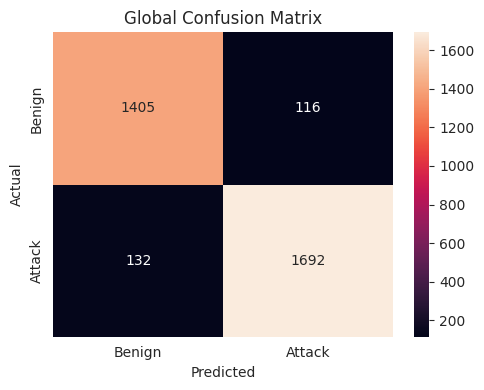


Class Distribution:
{np.int64(0): np.int64(1521), np.int64(1): np.int64(1824)}

Prediction Distribution:
{np.int64(0): np.int64(1537), np.int64(1): np.int64(1808)}


In [ ]:
import numpy as np

# ==========================================================
# GLOBAL EVALUATION
# ==========================================================

model.eval()

all_preds = []
all_true = []
all_probs = []

with torch.no_grad():

    for X_test, y_test in client_tests:

        X_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        logits = model(X_tensor)

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1].cpu().numpy()

        preds = (
            probs > best_thr
        ).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(
            np.asarray(y_test).astype(int)
        )

all_preds = np.asarray(all_preds)
all_true = np.asarray(all_true)
all_probs = np.asarray(all_probs)

global_acc = accuracy_score(
    all_true,
    all_preds
)

global_bacc = balanced_accuracy_score(
    all_true,
    all_preds
)

global_macro = f1_score(
    all_true,
    all_preds,
    average="macro",
    zero_division=0
)

global_precision = precision_score(
    all_true,
    all_preds,
    zero_division=0
)

global_recall = recall_score(
    all_true,
    all_preds,
    zero_division=0
)

global_auc = (
    roc_auc_score(
        all_true,
        all_probs
    )
    if len(np.unique(all_true)) > 1
    else float("nan")
)

print("\n" + "=" * 80)
print("GLOBAL PERFORMANCE (AGGREGATED)")
print("=" * 80)

print("Accuracy:", round(global_acc, 6))
print("Balanced Accuracy:", round(global_bacc, 6))
print("Macro F1:", round(global_macro, 6))
print("Precision:", round(global_precision, 6))
print("Recall:", round(global_recall, 6))

if not np.isnan(global_auc):
    print("AUC:", round(global_auc, 6))
else:
    print("AUC: N/A")

cm = confusion_matrix(
    all_true,
    all_preds,
    labels=[0, 1]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Benign","Attack"],
    yticklabels=["Benign","Attack"]
)

plt.title("Global Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(
    dict(
        zip(
            *np.unique(
                all_true,
                return_counts=True
            )
        )
    )
)

print("\nPrediction Distribution:")
print(
    dict(
        zip(
            *np.unique(
                all_preds,
                return_counts=True
            )
        )
    )
)


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# ==========================================================
# BOOTSTRAP STD FOR FINAL MODEL PERFORMANCE
# ==========================================================

N_BOOTSTRAPS = 1000


all_true = np.asarray(all_true)
all_pred = np.asarray(all_preds)
all_prob = np.asarray(all_probs)

n = len(all_true)

acc_scores = []
bacc_scores = []
f1_macro_scores = [] # Renamed from f1_scores
f1_weighted_scores = [] # Added for weighted F1
prec_scores = []
rec_scores = []
auc_scores = []

for _ in range(N_BOOTSTRAPS):
    # Resample with replacement
    idx = np.random.choice(
        np.arange(n),
        size=n,
        replace=True
    )

    y_true_bs = all_true[idx]
    y_pred_bs = all_pred[idx]
    y_prob_bs = all_prob[idx]

    acc_scores.append(
        accuracy_score(y_true_bs, y_pred_bs)
    )

    bacc_scores.append(
        balanced_accuracy_score(y_true_bs, y_pred_bs)
    )

    f1_macro_scores.append( # Appending to macro scores
        f1_score(
            y_true_bs,
            y_pred_bs,
            average="macro",
            zero_division=0
        )
    )

    f1_weighted_scores.append( # Appending to weighted scores
        f1_score(
            y_true_bs,
            y_pred_bs,
            average="weighted",
            zero_division=0
        )
    )

    prec_scores.append(
        precision_score(
            y_true_bs,
            y_pred_bs,
            zero_division=0
        )
    )

    rec_scores.append(
        recall_score(
            y_true_bs,
            y_pred_bs,
            zero_division=0
        )
    )

    # AUC requires at least two unique labels in y_true_bs
    if len(np.unique(y_true_bs)) > 1:
        auc_scores.append(
            roc_auc_score(
                y_true_bs,
                y_prob_bs
            )
        )
    else:
        auc_scores.append(np.nan) # Append NaN if AUC cannot be calculated

# ==========================================================
# FINAL TABLE
# ==========================================================

summary_df_bootstrap = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1", # New row
        "Precision",
        "Recall",
        "AUC"
    ],
    "Mean": [
        np.mean(acc_scores),
        np.mean(bacc_scores),
        np.mean(f1_macro_scores), # Use macro
        np.mean(f1_weighted_scores), # New mean
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.nanmean(auc_scores) # Use nanmean to handle potential NaNs from AUC calculation
    ],
    "Std Dev": [
        np.std(acc_scores),
        np.std(bacc_scores),
        np.std(f1_macro_scores), # Use macro
        np.std(f1_weighted_scores), # New std dev
        np.std(prec_scores),
        np.std(rec_scores),
        np.nanstd(auc_scores)
    ]
})

summary_df_bootstrap["Mean \u00B1 Std Dev"] = ( # Changed to unicode for ± and full column name
    summary_df_bootstrap["Mean"].round(4).astype(str)
    + " \u00B1 " # Changed to unicode for ±
    + summary_df_bootstrap["Std Dev"].round(4).astype(str)
)

print("\n" + "="*80)
print("BOOTSTRAP PERFORMANCE ESTIMATES")
print("="*80)

display(summary_df_bootstrap)


BOOTSTRAP PERFORMANCE ESTIMATES


,Metric,Mean,Std Dev,Mean ± Std Dev
0,Accuracy,0.925779,0.004468,0.9258 ± 0.0045
1,Balanced Accuracy,0.925607,0.004519,0.9256 ± 0.0045
2,Macro F1,0.925210,0.004498,0.9252 ± 0.0045
3,Weighted F1,0.925810,0.004467,0.9258 ± 0.0045
4,Precision,0.935829,0.005896,0.9358 ± 0.0059
5,Recall,0.927472,0.005940,0.9275 ± 0.0059
6,AUC,0.968242,0.003641,0.9682 ± 0.0036


In [ ]:
import pandas as pd
import numpy as np

# =============================================================================
# MAIN RESULTS TABLE
# =============================================================================

# Fetch means and stds from the already computed summary_df_bootstrap
# Create a mapping for metric names
metric_map = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1 Score (Macro)": "Macro F1",
    "F1 Score (Weighted)": "Weighted F1",
    "Balanced Accuracy": "Balanced Accuracy",
    "AUC-ROC": "AUC"
}

main_results_data = []
for display_metric, bootstrap_metric in metric_map.items():
    if bootstrap_metric in summary_df_bootstrap["Metric"].values:
        mean_val = summary_df_bootstrap[
            summary_df_bootstrap["Metric"] == bootstrap_metric
        ]["Mean"].iloc[0]
        std_val = summary_df_bootstrap[
            summary_df_bootstrap["Metric"] == bootstrap_metric
        ]["Std Dev"].iloc[0]

        # Format the mean and std dev as percentages
        formatted_value = f"{mean_val*100:.2f}% \u00B1 {std_val*100:.2f}%"
        main_results_data.append({"Metric": display_metric, "Value": formatted_value})
    else:
        # Fallback if a metric is not found in bootstrap (e.g., if AUC is NaN)
        # Use existing global_* values for single-run estimates if bootstrap mean/std are not available
        current_value = float("nan") # Default
        if display_metric == "Accuracy": current_value = global_acc
        elif display_metric == "Precision": current_value = global_precision
        elif display_metric == "Recall": current_value = global_recall
        elif display_metric == "F1 Score (Macro)": current_value = global_macro
        elif display_metric == "F1 Score (Weighted)": current_value = global_weighted_f1
        elif display_metric == "Balanced Accuracy": current_value = global_bacc
        elif display_metric == "AUC-ROC": current_value = global_auc

        if not np.isnan(current_value):
             main_results_data.append({"Metric": display_metric, "Value": f"{current_value*100:.2f}%"})
        else:
             main_results_data.append({"Metric": display_metric, "Value": "N/A"})


main_results = pd.DataFrame(main_results_data)

print("\n" + "="*80)
print("MAIN RESULTS TABLE (Mean \u00B1 Std Dev from Bootstrap)")
print("="*80)
print(main_results.to_string(index=False)) # Use to_string to avoid truncation if many rows

# =============================================================================
# DATASET PERFORMANCE
# =============================================================================

per_dataset_metrics = []

model.eval()
with torch.no_grad():
    for i, (X_test, y_test) in enumerate(client_tests):
        X_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        logits = model(X_tensor)
        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1].cpu().numpy()

        preds = (
            probs > best_thr
        ).astype(int)

        current_acc = accuracy_score(y_test, preds)
        current_bacc = balanced_accuracy_score(y_test, preds)
        current_macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
        current_weighted_f1 = f1_score(y_test, preds, average="weighted", zero_division=0)
        current_precision = precision_score(y_test, preds, zero_division=0)
        current_recall = recall_score(y_test, preds, zero_division=0)
        current_auc = (
            roc_auc_score(y_test, probs)
            if len(np.unique(y_test)) > 1
            else float("nan")
        )

        per_dataset_metrics.append({
            "Dataset": datasets[i],
            "Accuracy": round(current_acc * 100, 2),
            "Precision": round(current_precision * 100, 2),
            "Recall": round(current_recall * 100, 2),
            "F1 Score (Macro)": round(current_macro_f1 * 100, 2),
            "F1 Score (Weighted)": round(current_weighted_f1 * 100, 2),
            "Balanced Accuracy": round(current_bacc * 100, 2),
            "AUC-ROC": round(current_auc * 100, 2) if not np.isnan(current_auc) else np.nan
        })

results_df = pd.DataFrame(per_dataset_metrics)
dataset_df = results_df.copy()

print("\n" + "="*80)
print("PER DATASET RESULTS")
print("="*80)
print(dataset_df.to_string(index=False))

# =============================================================================
# TRUST SCORES
# =============================================================================

final_trust = trust_history[-1]

trust_df = pd.DataFrame({
    "Client": datasets,
    "Trust Score": final_trust
})

print("\n" + "="*80)
print("FINAL TRUST SCORES")
print("="*80)
print(trust_df.to_string(index=False))

# =============================================================================
# CLASS DISTRIBUTION
# =============================================================================

distribution_rows = []

for i, name in enumerate(datasets):
    X_train, y_train = client_trains[i]

    y_train = np.asarray(y_train)

    benign = np.sum(y_train == 0)
    attack = np.sum(y_train == 1)

    distribution_rows.append(
        [name, benign, attack]
    )

dist_df = pd.DataFrame(
    distribution_rows,
    columns=["Dataset", "Benign", "Attack"]
)

print("\n" + "="*80)
print("DATASET CLASS DISTRIBUTION")
print("="*80)
print(dist_df.to_string(index=False))

# =============================================================================
# PAPER READY TABLE
# =============================================================================

paper_table_data = []
for display_metric, bootstrap_metric in metric_map.items():
    if bootstrap_metric in summary_df_bootstrap["Metric"].values:
        mean_val = summary_df_bootstrap[
            summary_df_bootstrap["Metric"] == bootstrap_metric
        ]["Mean"].iloc[0]
        std_val = summary_df_bootstrap[
            summary_df_bootstrap["Metric"] == bootstrap_metric
        ]["Std Dev"].iloc[0]

        # Format the mean and std dev as percentages
        formatted_value = f"{mean_val*100:.2f}% \u00B1 {std_val*100:.2f}%"
        paper_table_data.append({"Metric": display_metric, "Value": formatted_value})
    else:
        # Fallback if a metric is not found in bootstrap (e.g., if AUC is NaN)
        current_value = float("nan") # Default
        if display_metric == "Accuracy": current_value = global_acc
        elif display_metric == "Precision": current_value = global_precision
        elif display_metric == "Recall": current_value = global_recall
        elif display_metric == "F1 Score (Macro)": current_value = global_macro
        elif display_metric == "F1 Score (Weighted)": current_value = global_weighted_f1
        elif display_metric == "Balanced Accuracy": current_value = global_bacc
        elif display_metric == "AUC-ROC": current_value = global_auc

        if not np.isnan(current_value):
             paper_table_data.append({"Metric": display_metric, "Value": f"{current_value*100:.2f}%"})
        else:
             paper_table_data.append({"Metric": display_metric, "Value": "N/A"})

paper_table = pd.DataFrame(paper_table_data)

print("\n" + "="*80)
print("PAPER READY RESULTS TABLE (Mean \u00B1 Std Dev from Bootstrap)")
print("="*80)
print(paper_table.to_string(index=False))

# =============================================================================
# SAVE EVERYTHING
# =============================================================================

# Save the tables as CSV, keeping the formatted string values
main_results.to_csv(
    "main_results_table.csv",
    index=False
)

dataset_df.to_csv(
    "per_dataset_results.csv",
    index=False
)

trust_df.to_csv(
    "trust_scores.csv",
    index=False
)

dist_df.to_csv(
    "class_distribution.csv",
    index=False
)

paper_table.to_csv(
    "paper_ready_results.csv",
    index=False
)

print("\nSaved Files:")
print("main_results_table.csv")
print("per_dataset_results.csv")
print("trust_scores.csv")
print("class_distribution.csv")
print("paper_ready_results.csv")


MAIN RESULTS TABLE (Mean ± Std Dev from Bootstrap)
             Metric          Value
           Accuracy 92.91% ± 0.45%
          Precision 97.32% ± 0.39%
             Recall 89.46% ± 0.73%
   F1 Score (Macro) 92.89% ± 0.45%
F1 Score (Weighted) 92.92% ± 0.45%
  Balanced Accuracy 93.25% ± 0.43%
            AUC-ROC 95.50% ± 0.40%

PER DATASET RESULTS
Dataset  Accuracy  Precision  Recall  F1 Score (Macro)  F1 Score (Weighted)  Balanced Accuracy  AUC-ROC
    CIC     93.93      57.77   96.75             84.47                94.60              95.21    98.70
   UNSW     72.80      84.49   68.40             72.44                73.17              74.13    77.77
    BoT     96.26     100.00   96.26             49.05                98.09              96.26      NaN

FINAL TRUST SCORES
Client  Trust Score
   CIC     0.340263
  UNSW     0.336510
   BoT     0.323227

DATASET CLASS DISTRIBUTION
Dataset  Benign  Attack
    CIC    6632     593
   UNSW     691    1115
    BoT       2    7076

PAPER 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Per-dataset Reviewer Metrics


REVIEWER EVALUATION

DATASET: CIC

Class Distribution
{np.int64(0): np.int64(1377), np.int64(1): np.int64(123)}

Predicted Distribution
{np.int64(0): np.int64(1294), np.int64(1): np.int64(206)}

Accuracy
0.939333

Balanced Accuracy
0.952149

Macro F1
0.844667

Weighted F1
0.946043

Confusion Matrix
[[1290   87]
 [   4  119]]


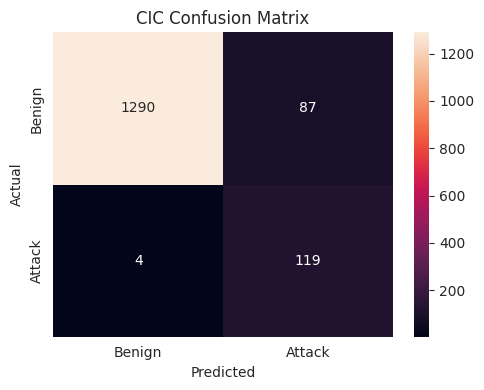


Classification Report
              precision    recall  f1-score   support

           0     0.9969    0.9368    0.9659      1377
           1     0.5777    0.9675    0.7234       123

    accuracy                         0.9393      1500
   macro avg     0.7873    0.9521    0.8447      1500
weighted avg     0.9625    0.9393    0.9460      1500


DATASET: UNSW

Class Distribution
{np.int64(0): np.int64(144), np.int64(1): np.int64(231)}

Predicted Distribution
{np.int64(0): np.int64(188), np.int64(1): np.int64(187)}

Accuracy
0.728

Balanced Accuracy
0.741297

Macro F1
0.724376

Weighted F1
0.731708

Confusion Matrix
[[115  29]
 [ 73 158]]


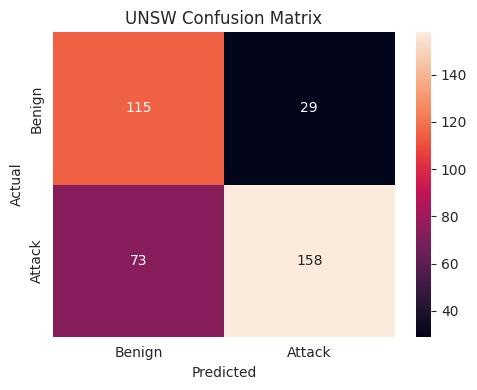


Classification Report
              precision    recall  f1-score   support

           0     0.6117    0.7986    0.6928       144
           1     0.8449    0.6840    0.7560       231

    accuracy                         0.7280       375
   macro avg     0.7283    0.7413    0.7244       375
weighted avg     0.7554    0.7280    0.7317       375


DATASET: BoT

Class Distribution
{np.int64(1): np.int64(1470)}

Predicted Distribution
{np.int64(0): np.int64(55), np.int64(1): np.int64(1415)}

Accuracy
0.962585

Balanced Accuracy
0.962585

Macro F1
0.490468

Weighted F1
0.980936

Confusion Matrix
[[   0    0]
 [  55 1415]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


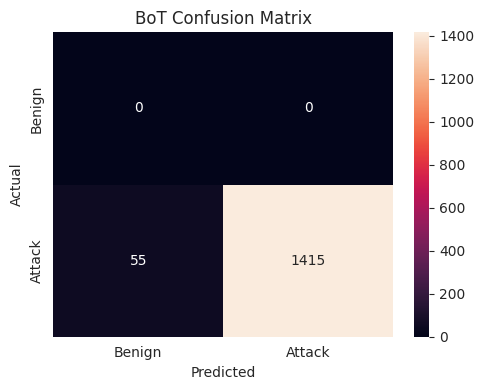


Classification Report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    0.9626    0.9809      1470

    accuracy                         0.9626      1470
   macro avg     0.5000    0.4813    0.4905      1470
weighted avg     1.0000    0.9626    0.9809      1470


REVIEWER SUMMARY TABLE
  Dataset  Accuracy  Balanced Accuracy  Macro F1  Weighted F1
0     CIC  0.939333           0.952149  0.844667     0.946043
1    UNSW  0.728000           0.741297  0.724376     0.731708
2     BoT  0.962585           0.962585  0.490468     0.980936


In [ ]:
import numpy as np
# ==========================================================
# Per-dataset Metrics
# ==========================================================
reviewer_results = []

print("\n" + "=" * 80)
print("REVIEWER EVALUATION")
print("=" * 80)

for ds_name, (X_test, y_test) in zip(datasets, client_tests):
    print("\n" + "=" * 60)
    print(f"DATASET: {ds_name}")
    print("=" * 60)

    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = (probs[:, 1] > best_thr).astype(int)

    acc = accuracy_score(y_test, preds)
    bacc = balanced_accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

    print("\nClass Distribution")
    unique, counts = np.unique(y_test, return_counts=True)
    print(dict(zip(unique, counts)))

    print("\nPredicted Distribution")
    unique, counts = np.unique(preds, return_counts=True)
    print(dict(zip(unique, counts)))

    print("\nAccuracy")
    print(round(acc, 6))

    print("\nBalanced Accuracy")
    print(round(bacc, 6))

    print("\nMacro F1")
    print(round(macro_f1, 6))

    print("\nWeighted F1")
    print(round(weighted_f1, 6))

    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    print("\nConfusion Matrix")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Benign","Attack"],
        yticklabels=["Benign","Attack"]
    )
    plt.title(f"{ds_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            preds,
            digits=4,
            zero_division=0,
            labels=[0, 1]
        )
    )

    reviewer_results.append([ds_name, acc, bacc, macro_f1, weighted_f1])

results_df = pd.DataFrame(
    reviewer_results,
    columns=["Dataset", "Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]
)

print("\n" + "=" * 80)
print("REVIEWER SUMMARY TABLE")
print("=" * 80)
print(results_df)

Optimal best_thr found: 0.7209 (Score: 0.9357)

REVIEWER EVALUATION

DATASET: CIC

Class Distribution
{np.int64(0): np.int64(1377), np.int64(1): np.int64(123)}

Predicted Distribution
{np.int64(0): np.int64(1368), np.int64(1): np.int64(132)}

Accuracy
0.972667

Balanced Accuracy
0.925882

Macro F1
0.91214

Confusion Matrix
[[1352   25]
 [  16  107]]


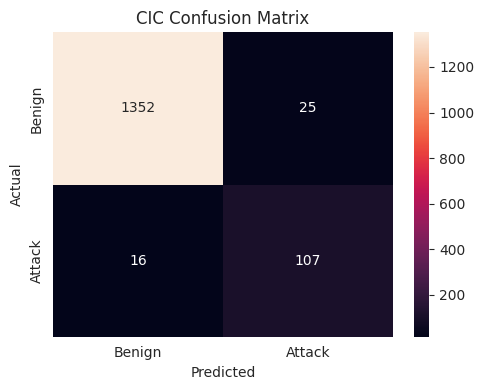


Classification Report
              precision    recall  f1-score   support

           0     0.9883    0.9818    0.9851      1377
           1     0.8106    0.8699    0.8392       123

    accuracy                         0.9727      1500
   macro avg     0.8995    0.9259    0.9121      1500
weighted avg     0.9737    0.9727    0.9731      1500


DATASET: UNSW

Class Distribution
{np.int64(0): np.int64(144), np.int64(1): np.int64(231)}

Predicted Distribution
{np.int64(0): np.int64(211), np.int64(1): np.int64(164)}

Accuracy
0.714667

Balanced Accuracy
0.742244

Macro F1
0.713853

Confusion Matrix
[[124  20]
 [ 87 144]]


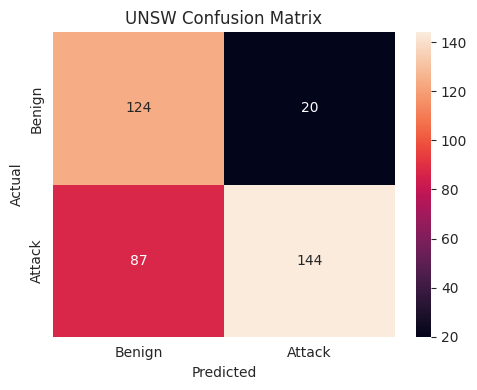


Classification Report
              precision    recall  f1-score   support

           0     0.5877    0.8611    0.6986       144
           1     0.8780    0.6234    0.7291       231

    accuracy                         0.7147       375
   macro avg     0.7329    0.7422    0.7139       375
weighted avg     0.7665    0.7147    0.7174       375


DATASET: BoT

Class Distribution
{np.int64(1): np.int64(1470)}

Predicted Distribution
{np.int64(0): np.int64(89), np.int64(1): np.int64(1381)}

Accuracy
0.939456

Balanced Accuracy
0.939456

Macro F1
0.484391

Confusion Matrix
[[   0    0]
 [  89 1381]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


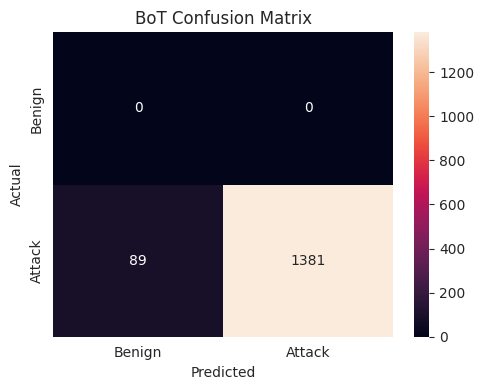


Classification Report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    0.9395    0.9688      1470

    accuracy                         0.9395      1470
   macro avg     0.5000    0.4697    0.4844      1470
weighted avg     1.0000    0.9395    0.9688      1470


REVIEWER SUMMARY TABLE
  Dataset  Accuracy  Balanced Accuracy  Macro F1
0     CIC  0.972667           0.925882  0.912140
1    UNSW  0.714667           0.742244  0.713853
2     BoT  0.939456           0.939456  0.484391


In [ ]:
# ==========================================================
# Calculate Per-dataset with best_thr
# ==========================================================

all_val_probs = []
all_val_true = []

model.eval()
with torch.no_grad():
    for X_val, y_val in client_vals:
        X_tensor = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_val_probs.extend(probs.cpu().numpy())
        all_val_true.extend(y_val)

all_val_probs = np.array(all_val_probs)
all_val_true = np.array(all_val_true)

best_thr = 0.5
best_score = -1

# Iterate through a range of possible thresholds
for t in np.linspace(0.01, 0.99, 500):
    preds = (all_val_probs > t).astype(int)
    bacc = balanced_accuracy_score(all_val_true, preds)
    macro_f1 = f1_score(all_val_true, preds, average="macro", zero_division=0)

    score = 0.5 * bacc + 0.5 * macro_f1 # Combine metrics for threshold optimization

    if score > best_score:
        best_score = score
        best_thr = t

print(f"Optimal best_thr found: {best_thr:.4f} (Score: {best_score:.4f})")

# ==========================================================
# Per-dataset Metrics
# ==========================================================
reviewer_results = []

print("\n" + "=" * 80)
print("REVIEWER EVALUATION")
print("=" * 80)

for ds_name, (X_test, y_test) in zip(datasets, client_tests):
    print("\n" + "=" * 60)
    print(f"DATASET: {ds_name}")
    print("=" * 60)

    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = (probs[:, 1] > best_thr).astype(int)

    acc = accuracy_score(y_test, preds)
    bacc = balanced_accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    print("\nClass Distribution")
    unique, counts = np.unique(y_test, return_counts=True)
    print(dict(zip(unique, counts)))

    print("\nPredicted Distribution")
    unique, counts = np.unique(preds, return_counts=True)
    print(dict(zip(unique, counts)))

    print("\nAccuracy")
    print(round(acc, 6))

    print("\nBalanced Accuracy")
    print(round(bacc, 6))

    print("\nMacro F1")
    print(round(macro_f1, 6))

    cm = confusion_matrix(y_test, preds)
    print("\nConfusion Matrix")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"]
    )
    plt.title(f"{ds_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            preds,
            digits=4,
            zero_division=0
        )
    )

    reviewer_results.append([ds_name, acc, bacc, macro_f1])

results_df = pd.DataFrame(
    reviewer_results,
    columns=["Dataset", "Accuracy", "Balanced Accuracy", "Macro F1"]
)

print("\n" + "=" * 80)
print("REVIEWER SUMMARY TABLE")
print("=" * 80)
print(results_df)


### REVIEWER ABLATION STUDY


In [ ]:
# ==========================================================
#  ABLATION CODE
# - per-model validation threshold
# - per-dataset Balanced Accuracy + Macro-F1
# - summary table
# ==========================================================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)

NUM_ROUNDS = 20

# ----------------------------------------------------------
# 1) Find best threshold on validation set for ONE model
# ----------------------------------------------------------
def find_best_threshold(model, client_vals, device, grid_size=500):
    model.eval()

    val_probs = []
    val_true = []

    with torch.no_grad():
        for X_val, y_val in client_vals:
            X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
            probs = torch.softmax(model(X_tensor), dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(np.asarray(y_val).astype(int))

    val_probs = np.asarray(val_probs)
    val_true = np.asarray(val_true).astype(int)

    best_thr = 0.5
    best_score = -1.0
    best_bacc = 0.0
    best_macro = 0.0

    for t in np.linspace(0.01, 0.99, grid_size):
        preds = (val_probs > t).astype(int)

        bacc = balanced_accuracy_score(val_true, preds)
        macro = f1_score(val_true, preds, average="macro", zero_division=0)

        score = 0.5 * bacc + 0.5 * macro

        if score > best_score:
            best_score = score
            best_thr = t
            best_bacc = bacc
            best_macro = macro

    return best_thr, best_score, best_bacc, best_macro


# ----------------------------------------------------------
# 2) Evaluate ONE model on the test sets with a chosen threshold
# ----------------------------------------------------------
def evaluate_model_on_tests(model, client_tests, datasets, device, threshold):
    model.eval()

    rows = []
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for ds_name, (X_test, y_test) in zip(datasets, client_tests):
            X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
            probs = torch.softmax(model(X_tensor), dim=1)[:, 1].cpu().numpy()
            preds = (probs > threshold).astype(int)

            y_test = np.asarray(y_test).astype(int)

            acc = accuracy_score(y_test, preds)
            bacc = balanced_accuracy_score(y_test, preds)
            macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)

            rows.append({
                "Dataset": ds_name,
                "Accuracy": acc,
                "Balanced Accuracy": bacc,
                "Macro F1": macro_f1
            })

            all_true.extend(y_test)
            all_pred.extend(preds)
            all_prob.extend(probs)

    all_true = np.asarray(all_true).astype(int)
    all_pred = np.asarray(all_pred).astype(int)
    all_prob = np.asarray(all_prob)

    global_acc = accuracy_score(all_true, all_pred)
    global_bacc = balanced_accuracy_score(all_true, all_pred)
    global_macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    global_precision = precision_score(all_true, all_pred, zero_division=0)
    global_recall = recall_score(all_true, all_pred, zero_division=0)
    global_auc = roc_auc_score(all_true, all_prob) if len(np.unique(all_true)) > 1 else float("nan")

    return rows, {
        "Accuracy": global_acc,
        "Balanced Accuracy": global_bacc,
        "Macro F1": global_macro_f1,
        "Precision": global_precision,
        "Recall": global_recall,
        "AUC": global_auc
    }


# ----------------------------------------------------------
# 3) Run one ablation experiment
# ----------------------------------------------------------
def run_ablation_experiment(
    name,
    use_trust=True,
    use_class_weights=True,
    use_sampler=True,
    use_mixup=True
):
    print(f"\nRunning: {name}")

    model_tmp, trust_hist_tmp, _ = federated_train(
        rounds=NUM_ROUNDS,
        use_trust=use_trust,
        use_class_weights=use_class_weights,
        use_sampler=use_sampler,
        use_mixup=use_mixup
    )

    # threshold is selected on validation for THIS model only
    local_thr, local_score, local_bacc_val, local_macro_val = find_best_threshold(
        model_tmp,
        client_vals=client_vals,
        device=DEVICE,
        grid_size=500
    )

    print(f"Validation threshold for {name}: {local_thr:.6f}")
    print(f"Validation score for {name}: {local_score:.6f}")

    per_dataset_rows, global_metrics = evaluate_model_on_tests(
        model_tmp,
        client_tests=client_tests,
        datasets=datasets,
        device=DEVICE,
        threshold=local_thr
    )

    for row in per_dataset_rows:
        row["Model"] = name
        row["Threshold"] = local_thr

    return per_dataset_rows, {
        "Model": name,
        "Threshold": local_thr,
        "Validation Score": local_score,
        "Validation BAcc": local_bacc_val,
        "Validation Macro F1": local_macro_val,
        **global_metrics
    }


# ----------------------------------------------------------
# 4) Run reviewer-specific imbalance ablation
# ----------------------------------------------------------
all_rows = []
summary_rows = []

experiments = [
    ("Full Model", True,  True,  True,  True),
    ("No Class Weights", True,  False, True,  True),
    ("No Sampler",       True,  True,  False, True),
    ("No Mixup",         True,  True,  True,  False),
]

for exp in experiments:
    name, use_trust, use_class_weights, use_sampler, use_mixup = exp

    rows, summary = run_ablation_experiment(
        name=name,
        use_trust=use_trust,
        use_class_weights=use_class_weights,
        use_sampler=use_sampler,
        use_mixup=use_mixup
    )

    all_rows.extend(rows)
    summary_rows.append(summary)

ablation_df = pd.DataFrame(all_rows)
ablation_summary_df = pd.DataFrame(summary_rows)


# ----------------------------------------------------------
# 5) Print raw per-dataset ablation results
# ----------------------------------------------------------
print("\n" + "=" * 80)
print("REVIEWER ABLATION RESULTS")
print("=" * 80)
print(ablation_df)

print("\n" + "=" * 80)
print("REVIEWER ABLATION SUMMARY")
print("=" * 80)
print(ablation_summary_df)


# ----------------------------------------------------------
# 6) Paper-ready pivot tables
# ----------------------------------------------------------
pivot_bacc = ablation_df.pivot_table(
    index="Model",
    columns="Dataset",
    values="Balanced Accuracy",
    aggfunc="mean"
)

pivot_macro = ablation_df.pivot_table(
    index="Model",
    columns="Dataset",
    values="Macro F1",
    aggfunc="mean"
)

print("\n" + "=" * 80)
print("PAPER READY ABLATION TABLE - BALANCED ACCURACY")
print("=" * 80)
print(pivot_bacc)

print("\n" + "=" * 80)
print("PAPER READY ABLATION TABLE - MACRO F1")
print("=" * 80)
print(pivot_macro)


# ----------------------------------------------------------
# 7) Mean across datasets
# ----------------------------------------------------------
ablation_mean_df = (
    ablation_df
    .groupby("Model")[["Balanced Accuracy", "Macro F1"]]
    .mean()
    .reset_index()
)

print("\n" + "=" * 80)
print("MEAN ABLATION PERFORMANCE ACROSS ALL DATASETS")
print("=" * 80)
print(ablation_mean_df)


# ----------------------------------------------------------
# 8) Save outputs
# ----------------------------------------------------------
ablation_df.to_csv("ablation_per_dataset_results.csv", index=False)
ablation_summary_df.to_csv("ablation_global_results.csv", index=False)
pivot_bacc.to_csv("ablation_pivot_balanced_accuracy.csv")
pivot_macro.to_csv("ablation_pivot_macro_f1.csv")
ablation_mean_df.to_csv("ablation_mean_across_datasets.csv", index=False)

print("\nSaved:")
print("ablation_per_dataset_results.csv")
print("ablation_global_results.csv")
print("ablation_pivot_balanced_accuracy.csv")
print("ablation_pivot_macro_f1.csv")
print("ablation_mean_across_datasets.csv")


Running: Full Model
Round 1/20 trust (trust-weighted): [0.3129 0.3934 0.2937]
Round 2/20 trust (trust-weighted): [0.3142 0.3861 0.2998]
Round 3/20 trust (trust-weighted): [0.3189 0.3762 0.3048]
Round 4/20 trust (trust-weighted): [0.3207 0.3711 0.3082]
Round 5/20 trust (trust-weighted): [0.3236 0.3655 0.3109]
Round 6/20 trust (trust-weighted): [0.3265 0.3623 0.3112]
Round 7/20 trust (trust-weighted): [0.33   0.3565 0.3135]
Round 8/20 trust (trust-weighted): [0.3334 0.3493 0.3172]
Round 9/20 trust (trust-weighted): [0.3344 0.3483 0.3173]
Round 10/20 trust (trust-weighted): [0.3362 0.3434 0.3203]
Round 11/20 trust (trust-weighted): [0.3428 0.3484 0.3088]
Round 12/20 trust (trust-weighted): [0.3416 0.3475 0.3108]
Round 13/20 trust (trust-weighted): [0.3426 0.35   0.3074]
Round 14/20 trust (trust-weighted): [0.3424 0.3491 0.3085]
Round 15/20 trust (trust-weighted): [0.3434 0.3473 0.3093]
Round 16/20 trust (trust-weighted): [0.3429 0.3473 0.3098]
Round 17/20 trust (trust-weighted): [0.3443 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Round 1/20 trust (trust-weighted): [0.3098 0.3953 0.2949]
Round 2/20 trust (trust-weighted): [0.3172 0.3826 0.3002]
Round 3/20 trust (trust-weighted): [0.3231 0.3744 0.3026]
Round 4/20 trust (trust-weighted): [0.323  0.3686 0.3085]
Round 5/20 trust (trust-weighted): [0.3282 0.3654 0.3064]
Round 6/20 trust (trust-weighted): [0.3334 0.3607 0.3059]
Round 7/20 trust (trust-weighted): [0.3381 0.3538 0.3081]
Round 8/20 trust (trust-weighted): [0.3389 0.3513 0.3098]
Round 9/20 trust (trust-weighted): [0.3429 0.3536 0.3036]
Round 10/20 trust (trust-weighted): [0.3453 0.3553 0.2994]
Round 11/20 trust (trust-weighted): [0.3442 0.3542 0.3017]
Round 12/20 trust (trust-weighted): [0.3472 0.3511 0.3017]
Round 13/20 trust (trust-weighted): [0.3435 0.35   0.3065]
Round 14/20 trust (trust-weighted): [0.343  0.3508 0.3063]
Round 15/20 trust (trust-weighted): [0.3419 0.3508 0.3073]
Round 16/20 trust (trust-weighted): [0.3416 0.3492 0.3092]
Round 17/20 trust (trust-weighted): [0.341  0.3472 0.3118]
Round 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Round 1/20 trust (trust-weighted): [0.3157 0.3554 0.3289]
Round 2/20 trust (trust-weighted): [0.3148 0.3542 0.331 ]
Round 3/20 trust (trust-weighted): [0.3137 0.3533 0.333 ]
Round 4/20 trust (trust-weighted): [0.3137 0.3527 0.3336]
Round 5/20 trust (trust-weighted): [0.3131 0.3528 0.3341]
Round 6/20 trust (trust-weighted): [0.3136 0.3509 0.3355]
Round 7/20 trust (trust-weighted): [0.3169 0.3491 0.334 ]
Round 8/20 trust (trust-weighted): [0.3165 0.3488 0.3346]
Round 9/20 trust (trust-weighted): [0.3185 0.3475 0.334 ]
Round 10/20 trust (trust-weighted): [0.3181 0.3471 0.3347]
Round 11/20 trust (trust-weighted): [0.3226 0.3435 0.3339]
Round 12/20 trust (trust-weighted): [0.3238 0.3432 0.3331]
Round 13/20 trust (trust-weighted): [0.3244 0.3426 0.333 ]
Round 14/20 trust (trust-weighted): [0.3265 0.3402 0.3333]
Round 15/20 trust (trust-weighted): [0.3258 0.3409 0.3333]
Round 16/20 trust (trust-weighted): [0.3264 0.3408 0.3328]
Round 17/20 trust (trust-weighted): [0.327 0.34  0.333]
Round 18/

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Round 1/20 trust (trust-weighted): [0.3087 0.4224 0.2688]
Round 2/20 trust (trust-weighted): [0.3179 0.4024 0.2797]
Round 3/20 trust (trust-weighted): [0.3245 0.393  0.2826]
Round 4/20 trust (trust-weighted): [0.3296 0.3842 0.2863]
Round 5/20 trust (trust-weighted): [0.3365 0.3779 0.2856]
Round 6/20 trust (trust-weighted): [0.3426 0.3786 0.2788]
Round 7/20 trust (trust-weighted): [0.3488 0.3739 0.2772]
Round 8/20 trust (trust-weighted): [0.3514 0.3726 0.276 ]
Round 9/20 trust (trust-weighted): [0.3523 0.3699 0.2778]
Round 10/20 trust (trust-weighted): [0.3517 0.3657 0.2826]
Round 11/20 trust (trust-weighted): [0.3486 0.3611 0.2903]
Round 12/20 trust (trust-weighted): [0.3456 0.3588 0.2956]
Round 13/20 trust (trust-weighted): [0.3453 0.3544 0.3002]
Round 14/20 trust (trust-weighted): [0.3414 0.3541 0.3046]
Round 15/20 trust (trust-weighted): [0.3406 0.3521 0.3074]
Round 16/20 trust (trust-weighted): [0.3409 0.3501 0.309 ]
Round 17/20 trust (trust-weighted): [0.3395 0.3498 0.3107]
Round 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
# ==========================================================
# TABLE 8
# FGSM ROBUSTNESS
# ==========================================================

# FGSM Attack function definition
def fgsm_attack(model, X, y, epsilon, criterion):
    # Ensure input tensor requires gradients
    X.requires_grad = True

    # Forward pass
    output = model(X)
    loss = criterion(output, y)

    # Zero all existing gradients
    model.zero_grad()

    # Calculate gradients of loss w.r.t X
    loss.backward()

    # Collect the sign of the gradients
    sign_data_grad = X.grad.data.sign()

    # Create adversarial example
    # No explicit clipping to fixed bounds, as features are StandardScaler-scaled.
    adv_x = X.data + epsilon * sign_data_grad

    return adv_x

criterion = nn.CrossEntropyLoss()

FGSM_EPSILONS = [0.0, 0.005, 0.01, 0.05, 0.1, 0.2]

fgsm_results = []

for epsilon in FGSM_EPSILONS:

    all_true = []
    all_pred = []

    for X_test, y_test in client_tests:

        X_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        y_tensor = torch.tensor(
            y_test,
            dtype=torch.long
        ).to(DEVICE)

        adv_x = fgsm_attack(
            model,
            X_tensor,
            y_tensor,
            epsilon,
            criterion
        )

        with torch.no_grad():

            logits = model(
                adv_x
            )

            preds = torch.argmax(
                logits,
                dim=1
            ).cpu().numpy()

        all_pred.extend(preds)

        all_true.extend(y_test)

    fgsm_results.append({

        "FGSM Epsilon": epsilon,

        "Accuracy":
        accuracy_score(
            all_true,
            all_pred
        ),

        "Balanced Accuracy":
        balanced_accuracy_score(
            all_true,
            all_pred
        ),

        "Macro F1":
        f1_score(
            all_true,
            all_pred,
            average="macro",
            zero_division=0
        )
    })

fgsm_df = pd.DataFrame(
    fgsm_results
)

display(fgsm_df)

,FGSM Epsilon,Accuracy,Balanced Accuracy,Macro F1
0,0.000,0.925561,0.925300,0.924997
1,0.005,0.755755,0.758949,0.755481
2,0.010,0.662481,0.669764,0.662350
3,0.050,0.175486,0.187668,0.163945
4,0.100,0.117489,0.124167,0.114030
5,0.200,0.095665,0.100279,0.094078


In [ ]:
# ==========================================================
# FAST DIFFERENTIAL PRIVACY EVALUATION
# ==========================================================

import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

# Use slightly larger sigmas first to verify that DP is actually changing the model
DP_SIGMAS = [
    0.000,
    0.001,
    0.005,
    0.010
]

def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


dp_results = []

for sigma in DP_SIGMAS:

    print("\n" + "=" * 80)
    print(f"Running DP sigma = {sigma}")
    print("=" * 80)

    reset_seed(42)

    CURRENT_DP_SIGMA = sigma
    print(f"CURRENT_DP_SIGMA = {CURRENT_DP_SIGMA}")

    # Train a DP-aware federated model
    model_dp, _, _ = federated_train(
        rounds=20,
        local_epochs=8
    )

    # ------------------------------------------------------
    # Validation threshold for THIS DP model
    # ------------------------------------------------------
    val_probs = []
    val_true = []

    model_dp.eval()
    with torch.no_grad():
        for X_val, y_val in client_vals:
            X_tensor = torch.tensor(
                X_val,
                dtype=torch.float32
            ).to(DEVICE)

            probs = torch.softmax(
                model_dp(X_tensor),
                dim=1
            )[:, 1]

            val_probs.extend(
                probs.cpu().numpy()
            )
            val_true.extend(
                y_val
            )

    val_probs = np.array(val_probs)
    val_true = np.array(val_true)

    best_thr_dp = 0.5
    best_score = -1

    for t in np.linspace(0.01, 0.99, 500):

        preds = (val_probs > t).astype(int)

        bacc = balanced_accuracy_score(
            val_true,
            preds
        )

        macro = f1_score(
            val_true,
            preds,
            average="macro",
            zero_division=0
        )

        score = 0.5 * bacc + 0.5 * macro

        if score > best_score:
            best_score = score
            best_thr_dp = t

    # ------------------------------------------------------
    # Test Evaluation
    # ------------------------------------------------------
    all_probs = []
    all_true = []

    model_dp.eval()
    with torch.no_grad():
        for X_test, y_test in client_tests:
            X_tensor = torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)

            probs = torch.softmax(
                model_dp(X_tensor),
                dim=1
            )[:, 1]

            all_probs.extend(
                probs.cpu().numpy()
            )
            all_true.extend(
                y_test
            )

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    preds = (all_probs > best_thr_dp).astype(int)

    dp_results.append({
        "Noise Sigma": sigma,
        "Accuracy": accuracy_score(all_true, preds),
        "Balanced Accuracy": balanced_accuracy_score(all_true, preds),
        "Macro F1": f1_score(all_true, preds, average="macro", zero_division=0),
        "AUC": roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) > 1 else float("nan")
    })

dp_df = pd.DataFrame(dp_results)

print("\n" + "=" * 80)
print("TABLE 7: DIFFERENTIAL PRIVACY RESULTS")
print("=" * 80)

display(dp_df.round(6))

dp_df.to_csv(
    "Table7_Differential_Privacy.csv",
    index=False
)

print("\nSaved: Table7_Differential_Privacy.csv")


Running DP sigma = 0.0
CURRENT_DP_SIGMA = 0.0
Round 1/20 trust (trust-weighted): [0.3158 0.4025 0.2817]
Round 2/20 trust (trust-weighted): [0.3146 0.39   0.2953]
Round 3/20 trust (trust-weighted): [0.3184 0.3751 0.3065]
Round 4/20 trust (trust-weighted): [0.3214 0.3683 0.3103]
Round 5/20 trust (trust-weighted): [0.3221 0.3582 0.3198]
Round 6/20 trust (trust-weighted): [0.3263 0.355  0.3187]
Round 7/20 trust (trust-weighted): [0.3303 0.3443 0.3254]
Round 8/20 trust (trust-weighted): [0.3309 0.346  0.3231]
Round 9/20 trust (trust-weighted): [0.3355 0.3464 0.3181]
Round 10/20 trust (trust-weighted): [0.3394 0.3441 0.3165]
Round 11/20 trust (trust-weighted): [0.3425 0.3499 0.3076]
Round 12/20 trust (trust-weighted): [0.3411 0.3489 0.31  ]
Round 13/20 trust (trust-weighted): [0.3431 0.349  0.3079]
Round 14/20 trust (trust-weighted): [0.3445 0.3487 0.3068]
Round 15/20 trust (trust-weighted): [0.346  0.3483 0.3057]
Round 16/20 trust (trust-weighted): [0.3428 0.3458 0.3114]
Round 17/20 trust 

,Noise Sigma,Accuracy,Balanced Accuracy,Macro F1,AUC
0,0.000,0.907623,0.910163,0.907349,0.958453
1,0.001,0.910015,0.913011,0.909793,0.959778
2,0.005,0.897160,0.901879,0.897070,0.958279
3,0.010,0.885202,0.885126,0.884443,0.936381



Saved: Table7_Differential_Privacy.csv


In [ ]:
# ==========================================================
# DIFFERENTIAL PRIVACY EVALUATION
# ==========================================================

import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

# Use slightly larger sigmas first to verify that DP is actually changing the model
DP_SIGMAS = [
    0.000,
    0.001,
    0.005,
    0.010
]

def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


dp_results = []

for sigma in DP_SIGMAS:

    print("\n" + "=" * 80)
    print(f"Running DP sigma = {sigma}")
    print("=" * 80)

    reset_seed(42)

    CURRENT_DP_SIGMA = sigma
    print(f"CURRENT_DP_SIGMA = {CURRENT_DP_SIGMA}")

    # Train a DP-aware federated model
    model_dp, _, _ = federated_train(
        rounds=20,
        local_epochs=8
    )

    # ------------------------------------------------------
    # Validation threshold for THIS DP model
    # ------------------------------------------------------
    val_probs = []
    val_true = []

    model_dp.eval()
    with torch.no_grad():
        for X_val, y_val in client_vals:
            X_tensor = torch.tensor(
                X_val,
                dtype=torch.float32
            ).to(DEVICE)

            probs = torch.softmax(
                model_dp(X_tensor),
                dim=1
            )[:, 1]

            val_probs.extend(
                probs.cpu().numpy()
            )
            val_true.extend(
                y_val
            )

    val_probs = np.array(val_probs)
    val_true = np.array(val_true)

    best_thr_dp = 0.5
    best_score = -1

    for t in np.linspace(0.01, 0.99, 500):

        preds = (val_probs > t).astype(int)

        bacc = balanced_accuracy_score(
            val_true,
            preds
        )

        macro = f1_score(
            val_true,
            preds,
            average="macro",
            zero_division=0
        )

        score = 0.5 * bacc + 0.5 * macro

        if score > best_score:
            best_score = score
            best_thr_dp = t

    # ------------------------------------------------------
    # Test Evaluation
    # ------------------------------------------------------
    all_probs = []
    all_true = []

    model_dp.eval()
    with torch.no_grad():
        for X_test, y_test in client_tests:
            X_tensor = torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)

            probs = torch.softmax(
                model_dp(X_tensor),
                dim=1
            )[:, 1]

            all_probs.extend(
                probs.cpu().numpy()
            )
            all_true.extend(
                y_test
            )

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    preds = (all_probs > best_thr_dp).astype(int)

    dp_results.append({
        "Noise Sigma": sigma,
        "Accuracy": accuracy_score(all_true, preds),
        "Balanced Accuracy": balanced_accuracy_score(all_true, preds),
        "Macro F1": f1_score(all_true, preds, average="macro", zero_division=0),
        "AUC": roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) > 1 else float("nan")
    })

dp_df = pd.DataFrame(dp_results)

print("\n" + "=" * 80)
print("TABLE 7: DIFFERENTIAL PRIVACY RESULTS")
print("=" * 80)

display(dp_df.round(6))

dp_df.to_csv(
    "Table7_Differential_Privacy.csv",
    index=False
)

print("\nSaved: Table7_Differential_Privacy.csv")


Running DP sigma = 0.0
CURRENT_DP_SIGMA = 0.0
Round 1/20 trust (trust-weighted): [0.3158 0.4025 0.2817]
Round 2/20 trust (trust-weighted): [0.3146 0.39   0.2953]
Round 3/20 trust (trust-weighted): [0.3184 0.3751 0.3065]
Round 4/20 trust (trust-weighted): [0.3214 0.3683 0.3103]
Round 5/20 trust (trust-weighted): [0.3221 0.3582 0.3198]
Round 6/20 trust (trust-weighted): [0.3263 0.355  0.3187]
Round 7/20 trust (trust-weighted): [0.3303 0.3443 0.3254]
Round 8/20 trust (trust-weighted): [0.3309 0.346  0.3231]
Round 9/20 trust (trust-weighted): [0.3355 0.3464 0.3181]
Round 10/20 trust (trust-weighted): [0.3394 0.3441 0.3165]
Round 11/20 trust (trust-weighted): [0.3425 0.3499 0.3076]
Round 12/20 trust (trust-weighted): [0.3411 0.3489 0.31  ]
Round 13/20 trust (trust-weighted): [0.3431 0.349  0.3079]
Round 14/20 trust (trust-weighted): [0.3445 0.3487 0.3068]
Round 15/20 trust (trust-weighted): [0.346  0.3483 0.3057]
Round 16/20 trust (trust-weighted): [0.3428 0.3458 0.3114]
Round 17/20 trust 

,Noise Sigma,Accuracy,Balanced Accuracy,Macro F1,AUC
0,0.000,0.907623,0.910163,0.907349,0.958453
1,0.001,0.910015,0.913011,0.909793,0.959778
2,0.005,0.897160,0.901879,0.897070,0.958279
3,0.010,0.885202,0.885126,0.884443,0.936381



Saved: Table7_Differential_Privacy.csv




GLOBAL METRICS
                Metric     Value
0             Accuracy  0.925859
1    Balanced Accuracy  0.925683
2  F1 Score (Weighted)  0.925890
3                  AUC  0.968314


DATASET PERFORMANCE
  Dataset  Accuracy  Balanced Accuracy  F1 Score (Weighted)
0     CIC  0.939333           0.952149             0.946043
1    UNSW  0.728000           0.741297             0.731708
2     BoT  0.962585           0.962585             0.980936


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


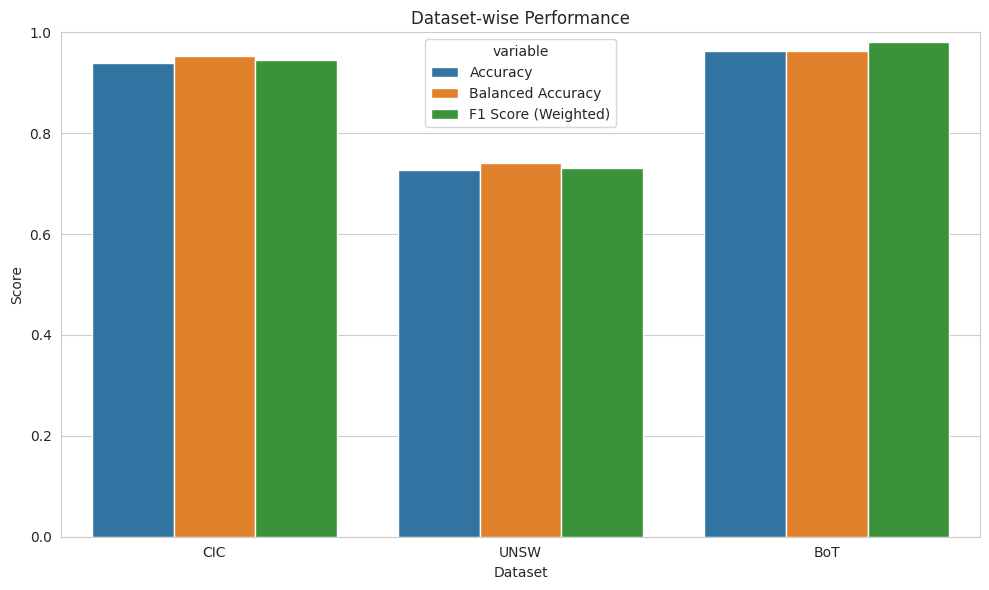

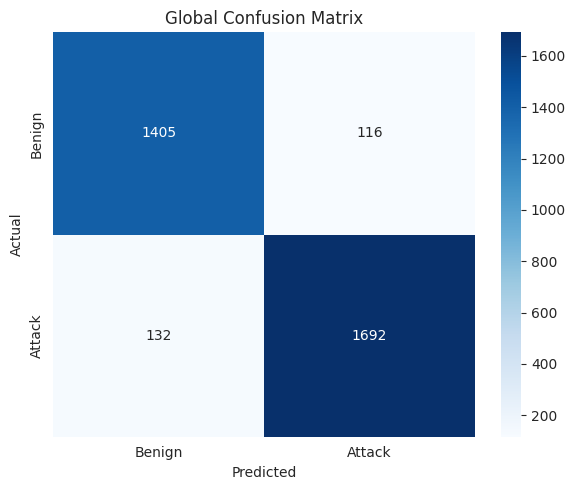

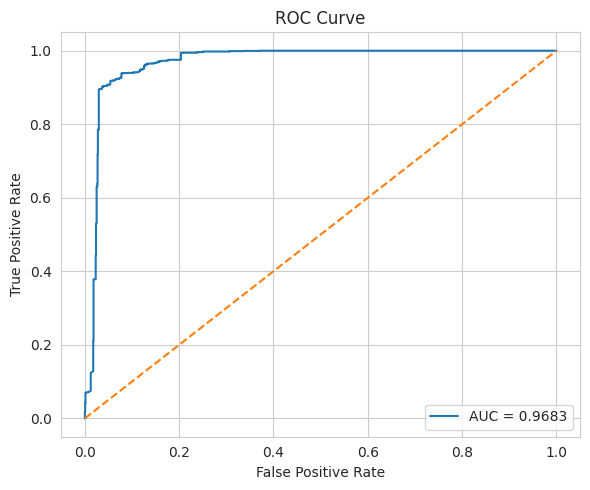

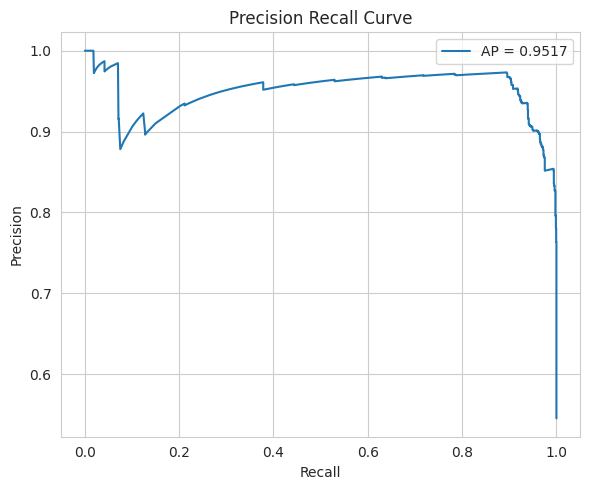

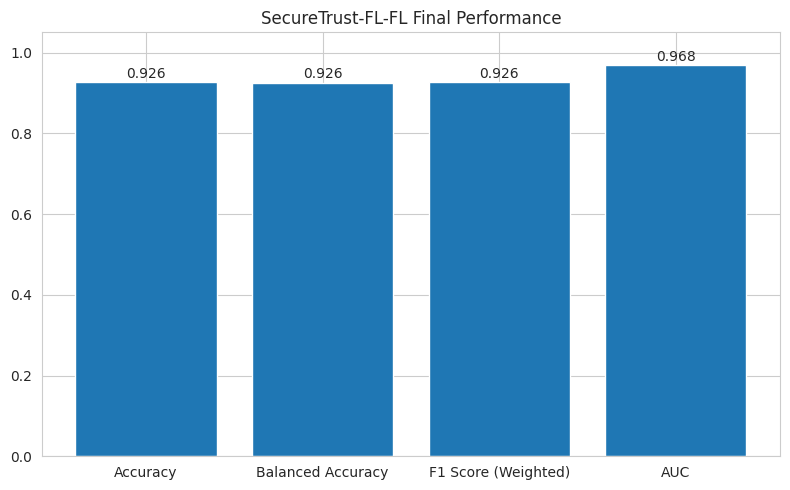


Best Threshold Used: 0.5108016032064129


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

sns.set_style("whitegrid")

# ==========================================================
# GLOBAL PREDICTIONS
# ==========================================================

all_true = []
all_probs = []

model.eval()

with torch.no_grad():

    for X_test, y_test in client_tests:

        X_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        logits = model(X_tensor)

        probs = torch.softmax(
            logits,
            dim=1
        )[:,1]

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_true.extend(
            y_test
        )

all_true = np.array(all_true)
all_probs = np.array(all_probs)

# ==========================================================
# USE BEST THRESHOLD FOUND DURING TRAINING
# ==========================================================

all_preds = (
    all_probs > best_thr
).astype(int)

# ==========================================================
# GLOBAL METRICS
# ==========================================================

global_acc = accuracy_score(
    all_true,
    all_preds
)

global_bacc = balanced_accuracy_score(
    all_true,
    all_preds
)

global_weighted_f1 = f1_score( # Changed to weighted F1
    all_true,
    all_preds,
    average="weighted",
    zero_division=0
)

global_auc = roc_auc_score(
    all_true,
    all_probs
)

global_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "F1 Score (Weighted)", # Changed metric name
        "AUC"
    ],

    "Value":[
        global_acc,
        global_bacc,
        global_weighted_f1, # Using weighted F1
        global_auc
    ]
})

print("\n")
print("="*80)
print("GLOBAL METRICS")
print("="*80)
print(global_table)

# ==========================================================
# DATASET PERFORMANCE
# ==========================================================

dataset_results = []

for ds_name, (X_test, y_test) in zip(
    datasets, # Using datasets variable
    client_tests
):

    with torch.no_grad():

        X_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        logits = model(X_tensor)

        probs = torch.softmax(
            logits,
            dim=1
        )[:,1].cpu().numpy()

        preds = (
            probs > best_thr
        ).astype(int)

    acc = accuracy_score(
        y_test,
        preds
    )

    bacc = balanced_accuracy_score(
        y_test,
        preds
    )

    weighted_f1 = f1_score( # Changed to weighted F1
        y_test,
        preds,
        average="weighted",
        zero_division=0
    )

    dataset_results.append([
        ds_name,
        acc,
        bacc,
        weighted_f1 # Using weighted F1
    ])

dataset_df = pd.DataFrame(
    dataset_results,
    columns=[
        "Dataset",
        "Accuracy",
        "Balanced Accuracy",
        "F1 Score (Weighted)" # Changed column name
    ]
)

print("\n")
print("="*80)
print("DATASET PERFORMANCE")
print("="*80)
print(dataset_df)

# ==========================================================
# DATASET PERFORMANCE PLOT
# ==========================================================

plot_df = dataset_df.melt(
    id_vars="Dataset"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    x="Dataset",
    y="value",
    hue="variable"
)

plt.title(
    "Dataset-wise Performance"
)

plt.ylabel(
    "Score"
)

plt.ylim(0,1)

plt.tight_layout()

plt.show()

# ==========================================================
# GLOBAL CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    all_true,
    all_preds,
    labels=[0, 1]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Attack"],
    yticklabels=["Benign","Attack"]
)

plt.title(
    "Global Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(
    all_true,
    all_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# PRECISION RECALL CURVE
# ==========================================================

precision, recall, _ = precision_recall_curve(
    all_true,
    all_probs
)

ap = average_precision_score(
    all_true,
    all_probs
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision Recall Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# FINAL SUMMARY FIGURE
# ==========================================================

summary_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "F1 Score (Weighted)", # Changed metric name
        "AUC"
    ],

    "Score":[
        global_acc,
        global_bacc,
        global_weighted_f1, # Using weighted F1
        global_auc
    ]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    summary_df["Metric"],
    summary_df["Score"]
)

for b in bars:

    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height()+0.01,
        f"{b.get_height():.3f}",
        ha="center"
    )

plt.ylim(
    0,
    1.05
)

plt.title(
    "SecureTrust-FL-FL Final Performance"
)

plt.tight_layout()

plt.show()

print("\nBest Threshold Used:", best_thr)



FINAL TRUST SCORES
  Client  Trust Score
0    CIC     0.340941
1   UNSW     0.336860
2    BoT     0.322199


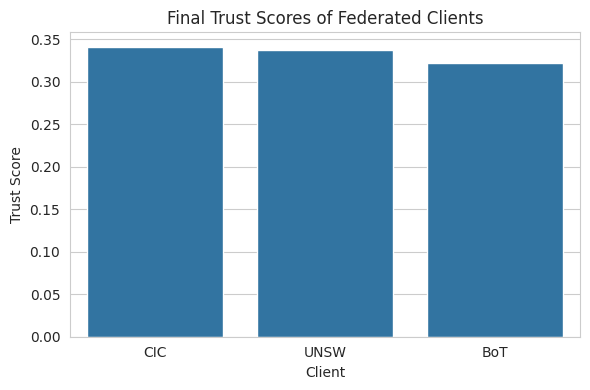

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# ==========================================================
# 1. Final Trust Score Table
# ==========================================================

if len(trust_history) > 0:

    final_trust = trust_history[-1]

    trust_df = pd.DataFrame({
        "Client": datasets,
        "Trust Score": final_trust
    })

    print("\n" + "="*80)
    print("FINAL TRUST SCORES")
    print("="*80)
    print(trust_df)

    trust_df.to_csv(
        "/content/trust_scores.csv",
        index=False
    )

    plt.figure(figsize=(6,4))

    sns.barplot(
        x="Client",
        y="Trust Score",
        data=trust_df
    )

    plt.title(
        "Final Trust Scores of Federated Clients"
    )

    plt.xlabel("Client")
    plt.ylabel("Trust Score")

    plt.tight_layout()
    plt.show()

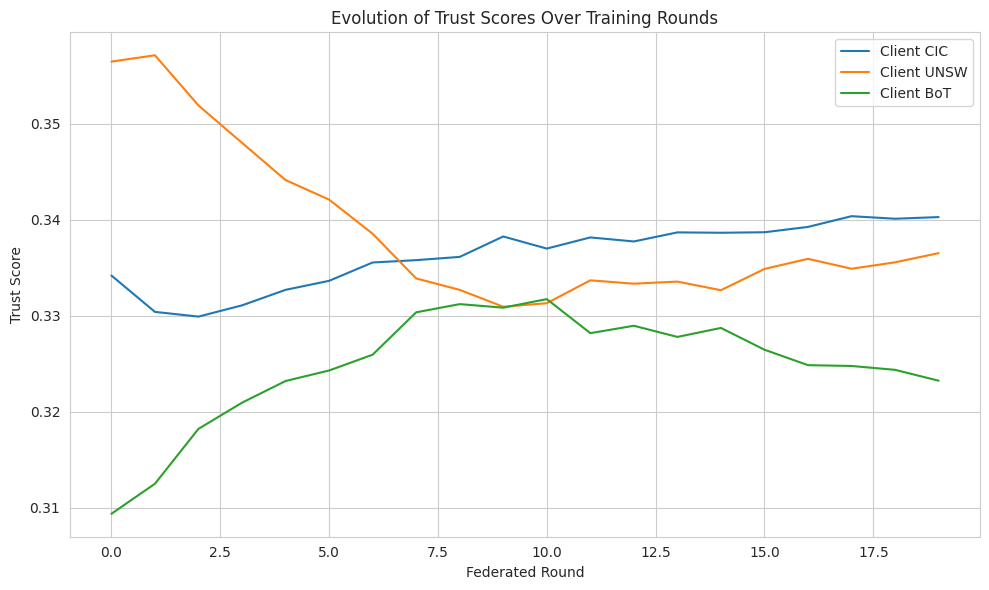

In [ ]:
trust_history_array = np.array(trust_history)

plt.figure(figsize=(10, 6))
for i, ds_name in enumerate(datasets):
    plt.plot(trust_history_array[:, i], label=f'Client {ds_name}')

plt.title('Evolution of Trust Scores Over Training Rounds')
plt.xlabel('Federated Round')
plt.ylabel('Trust Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

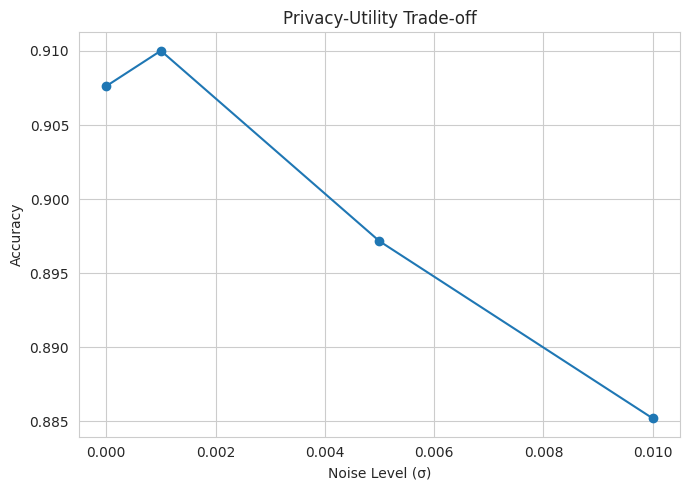

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    dp_df["Noise Sigma"],
    dp_df["Accuracy"],
    marker="o"
)

plt.title(
    "Privacy-Utility Trade-off"
)

plt.xlabel(
    "Noise Level (σ)"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.tight_layout()

plt.show()

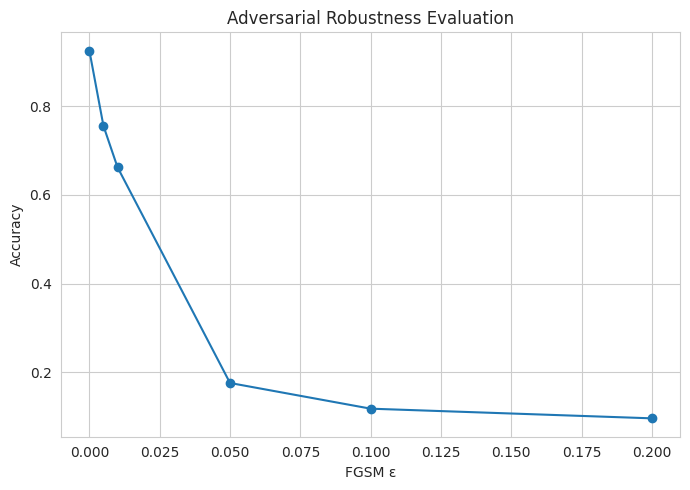

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    fgsm_df["FGSM Epsilon"],
    fgsm_df["Accuracy"],
    marker="o"
)

plt.title(
    "Adversarial Robustness Evaluation"
)

plt.xlabel(
    "FGSM ε"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.tight_layout()

plt.show()

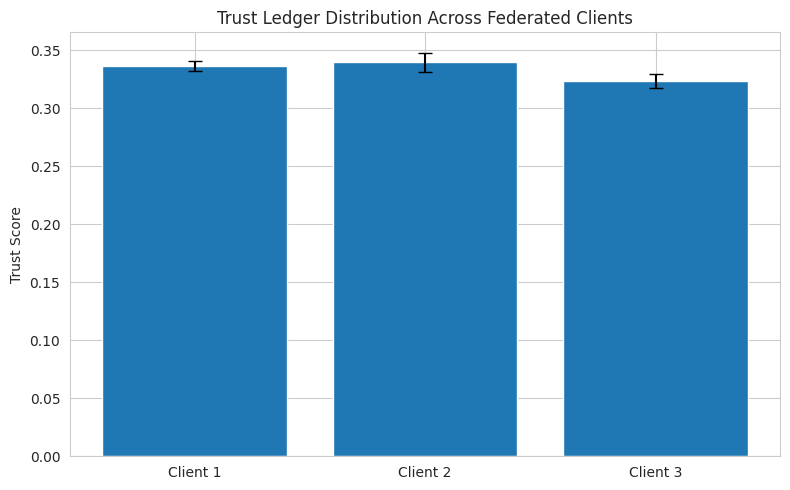

In [ ]:
trust_array = np.array(trust_history)

means = trust_array.mean(axis=0)
stds = trust_array.std(axis=0)

plt.figure(figsize=(8,5))

plt.bar(
    range(len(means)),
    means,
    yerr=stds,
    capsize=5
)

plt.xticks(
    range(len(means)),
    [f"Client {i+1}" for i in range(len(means))]
)

plt.ylabel("Trust Score")
plt.title("Trust Ledger Distribution Across Federated Clients")

plt.tight_layout()
plt.show()

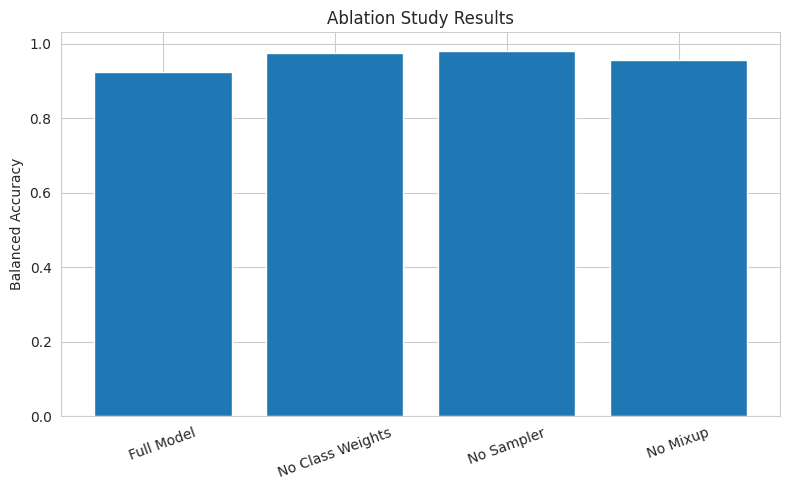

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation_df["Model"],
    ablation_df["Balanced Accuracy"]
)

plt.ylabel("Balanced Accuracy")
plt.title("Ablation Study Results")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("GLOBAL PERFORMANCE (AGGREGATED)")
print("="*80)
display(pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Precision",
        "Recall",
        "AUC"
    ],
    "Value": [
        round(global_acc, 6),
        round(global_bacc, 6),
        round(global_macro, 6),
        round(global_precision, 6),
        round(global_recall, 6),
        round(global_auc, 6) if not np.isnan(global_auc) else 'N/A'
    ]
}))


GLOBAL PERFORMANCE (AGGREGATED)


,Metric,Value
0,Accuracy,0.925859
1,Balanced Accuracy,0.925683
2,Macro F1,0.925310
3,Precision,0.935841
4,Recall,0.927632
5,AUC,0.968314


### Trust Scores Standard Deviation Across Rounds

In [ ]:
trust_array = np.array(trust_history)
means = trust_array.mean(axis=0)
stds = trust_array.std(axis=0)

std_df = pd.DataFrame({
    "Client": datasets,
    "Mean Trust Score": means,
    "Std Dev Trust Score": stds
})
print("\n" + "="*80)
print("TRUST SCORES MEAN AND STANDARD DEVIATION ACROSS ROUNDS")
print("="*80)
display(std_df)


TRUST SCORES MEAN AND STANDARD DEVIATION ACROSS ROUNDS


,Client,Mean Trust Score,Std Dev Trust Score
0,CIC,0.336316,0.003243
1,UNSW,0.338894,0.008056
2,BoT,0.324790,0.005772
